# StringForge: New databases for CY threefolds

This notebook demonstrates `StringForge`, the infrastructure layer of the `StringJAX` ecosystem that provides reproducible access to Calabi–Yau geometry databases and bridges them into physics engines such as `JAXVacua`. Two flavours of database are exposed here: **TDF** (trilayer, double-favourable anti-canonical hypersurfaces in toric varieties from the Kreuzer–Skarke list, [hep-th/0002240](https://arxiv.org/abs/hep-th/0002240)) and **CICY** (complete-intersection Calabi–Yau threefolds in products of projective spaces). The cells below show how to query the catalogues, load individual or batched geometries as `lcs_tree` objects in mirror convention, and feed them directly into the `JAXVacua`-based perturbatively flat vacua (PFV) workflow used elsewhere in lecture 2.

In [1]:
import stringforge
import jaxvacua as jvc

# Standard-library + pandas imports used by the catalogue / extra-data cells below.
import json
import pandas as pd
from IPython.display import Image

# The StringForge workflow

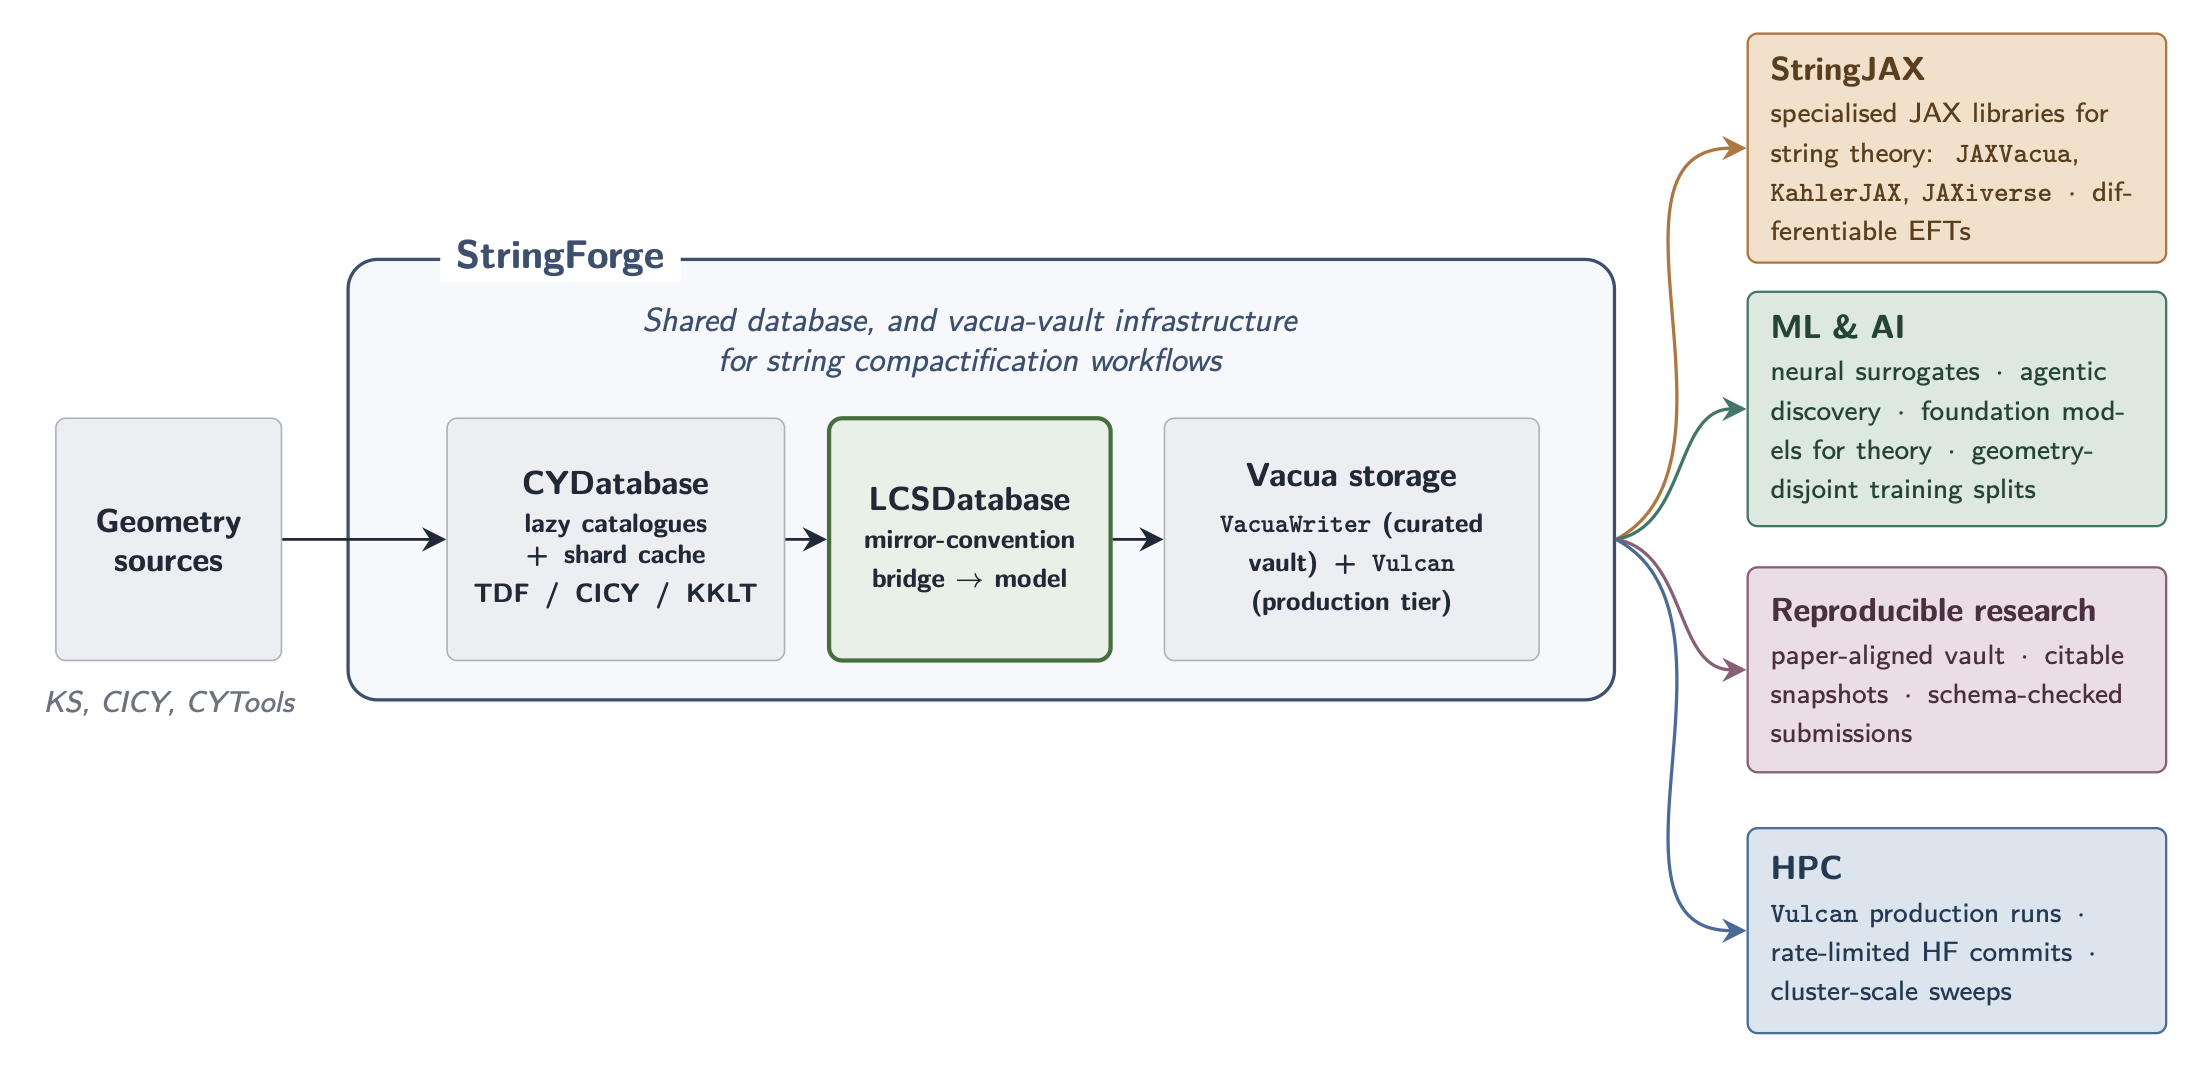

In [4]:
Image(filename='stringforge.png', width=1600, height=1100) 

## Load models

The **TDF** database collects Calabi–Yau threefolds realised as *trilayer, double-favourable* anti-canonical hypersurfaces in toric varieties from the Kreuzer–Skarke classification of 4D reflexive polytopes. Each model is identified by a pair `(ks_id, triang_id)`, where `ks_id` labels the polytope and `triang_id` labels a fine, regular, star triangulation of it.

In [ ]:
db = stringforge.CYDatabase("tdf")
db.info()

CYDatabase — sub-dataset: 'tdf'
  Total models : 950,909
  h11 range    : 2 – 11
  h12 range    : 29 – 491
  With GV data : 950,909  (100.0%)
  With conifolds: 900,586  (94.7%)
  Cache dir    : /Users/andreasschachner/Software/GitHub/lectures/unreasonable-torics/notebooks/.stringforge_cache/tdf


In [ ]:
db._catalog

,ks_id,triang_id,h11,h12,chi,lcs_shard_id,lcs_row_index,gv_shard_id,gv_row_index,has_gv,n_conifolds,conifold_shard_id,polytope_shard_id,polytope_row_index
0,557025,0,10,100,-180,0,0,0,0,True,1,0,10,623
1,557025,1,10,100,-180,0,1,0,1,True,1,0,10,623
2,557025,2,10,100,-180,0,2,0,2,True,2,0,10,623
3,557025,3,10,100,-180,0,3,0,3,True,2,0,10,623
4,557025,4,10,100,-180,0,4,0,4,True,2,0,10,623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950904,278347,11,9,97,-176,140,223,140,223,True,2,517,6,645
950905,278347,12,9,97,-176,140,224,140,224,True,2,517,6,645
950906,278347,13,9,97,-176,140,225,140,225,True,2,517,6,645
950907,278347,14,9,97,-176,140,226,140,226,True,2,517,6,645


In [ ]:
db.query(ks_id=557025)

,ks_id,triang_id,h11,h12,chi,lcs_shard_id,lcs_row_index,gv_shard_id,gv_row_index,has_gv,n_conifolds,conifold_shard_id,polytope_shard_id,polytope_row_index
0,557025,0,10,100,-180,0,0,0,0,True,1,0,10,623
1,557025,1,10,100,-180,0,1,0,1,True,1,0,10,623
2,557025,2,10,100,-180,0,2,0,2,True,2,0,10,623
3,557025,3,10,100,-180,0,3,0,3,True,2,0,10,623
4,557025,4,10,100,-180,0,4,0,4,True,2,0,10,623
5,557025,5,10,100,-180,0,5,0,5,True,2,0,10,623


We can use it to load models constructing the LCS periods as inputs for `jaxvacua`.

Here we load all of the models for a specific `ks_id` from the `tdf` database; `ks_id` is the Kreuzer–Skarke polytope identifier, and each polytope generally admits several triangulations, each yielding a distinct Calabi–Yau geometry.

In [ ]:
db = stringforge.LCSDatabase("tdf")
models_ks = db.load_batch(ks_id=557025)
models_ks 

[LCS-tree object with 
     h11  = 100
     h12  = 10,
 LCS-tree object with 
     h11  = 100
     h12  = 10,
 LCS-tree object with 
     h11  = 100
     h12  = 10,
 LCS-tree object with 
     h11  = 100
     h12  = 10,
 LCS-tree object with 
     h11  = 100
     h12  = 10,
 LCS-tree object with 
     h11  = 100
     h12  = 10]

Each model stores information about the LCS periods. E.g., we can look at the intersection numbers as follows

In [ ]:
model = models_ks[0]
model.intnums

Array([[[ 80,   8,   1,  14,   2,   0,   0,   0,   0,   0],
        [  8,   0,   1,   2,   0,   0,   0,   0,   0,   0],
        [  1,   1,  -3,   0,   1,   2,   0,   0,   0,   0],
        [ 14,   2,   0,  -4,   0,   0,   0,   0,   0,   2],
        [  2,   0,   1,   0,  -4,   0,   0,   0,   0,   0],
        [  0,   0,   2,   0,   0,  -4,   2,   0,   0,   0],
        [  0,   0,   0,   0,   0,   2,  -4,   0,   2,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   2,   0,  -4,   2],
        [  0,   0,   0,   2,   0,   0,   0,   0,   2,  -4]],

       [[  8,   0,   1,   2,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  1,   0,  -2,   0,   0,   2,   0,   1,   0,   0],
        [  2,   0,   0,  -2,   0,   0,   0,   0,   0,   2],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   2,   0,   0,  -4,   2,   0,   0,   0],
        [  0,   0,   0,   0,   0,   2,

Similarly, we can obtain all models at $h^{1,2}=2$

In [ ]:
models_h12_2 = db.load_batch(h12=2)
print(f"# of models loaded: ",len(models_h12_2))

# of models loaded:  11


We have now seen the full TDF workflow end-to-end: enumerating the catalogue, filtering by `ks_id`, loading all triangulations of a single polytope as a batch, inspecting the topological data on the resulting `lcs_tree` objects (intersection numbers, second Chern class, Euler characteristic), and finally pulling a batch across all polytopes at fixed `h12`. Because `load_batch` parallelises shard I/O behind a single catalogue query, the same pattern scales naturally to large-`h12` sweeps without further bookkeeping on the user side. The next section turns to the complete-intersection (CICY) database, which uses the same API but a different underlying construction of the geometry.

## Load CICYs

We can also load CICY threefolds in a similar way. The CICYs are the 7,890 complete-intersection Calabi–Yau threefolds first classified by Candelas, Dale, Lütken and Schimmrigk, realised as the vanishing locus of a set of homogeneous polynomials inside a product of complex projective spaces. StringForge ships 7,406 of these with precomputed topological data, of which 4,511 carry Gopakumar–Vafa invariants.

In [ ]:
cicys = stringforge.LCSDatabase("cicy")
cicys.info()

LCSDatabase — sub-dataset: 'cicy' (mirror convention)
  Total models : 7,406
  h11 range    : 0 – 19
  h12 range    : 0 – 101
  With GV data : 4,511  (60.9%)
  Cache dir    : /Users/andreasschachner/Software/GitHub/lectures/unreasonable-torics/notebooks/.stringforge_cache/cicy


In [ ]:
cicys._catalog

,cicy_id,h11,h12,chi,lcs_shard_id,lcs_row_index,gv_shard_id,gv_row_index,has_gv
0,31,0,0,0,0,0,<NA>,<NA>,False
1,32,0,0,0,0,1,<NA>,<NA>,False
2,33,0,0,0,0,2,<NA>,<NA>,False
3,34,0,0,0,0,3,<NA>,<NA>,False
4,35,0,0,0,0,4,<NA>,<NA>,False
...,...,...,...,...,...,...,...,...,...
7401,7886,86,2,168,0,1,45,6,True
7402,7887,86,2,168,0,2,45,7,True
7403,7888,86,2,168,0,3,45,8,True
7404,7889,89,1,176,0,0,45,9,True


We can query models e.g. by the `cicy_id`

In [ ]:
cicys.query(cicy_id=7447)

,cicy_id,h12,h11,lcs_shard_id,lcs_row_index,gv_shard_id,gv_row_index,has_gv
0,7447,45,5,0,11,41,53,True


This is the (mirror) of the **Hulek–Verrill** Calabi–Yau threefold (CICY index 7447). The Hulek–Verrill family is a distinguished CICY whose periods are tied to a weight-4 modular form, giving it a rich arithmetic structure that has made it a recurring test case for period computations and flux-vacuum studies.

In [ ]:
model = cicys.load(cicy_id=7447)

(f"intersection numbers (coo format): {model.intnums_coo.astype(int).tolist()}",
f"Euler character: {model.chi}",
f"Second Chern class: {model.c2}")

('intersection numbers (coo format): [[0, 1, 2, 2], [0, 1, 3, 2], [0, 1, 4, 2], [0, 2, 3, 2], [0, 2, 4, 2], [0, 3, 4, 2], [1, 2, 3, 2], [1, 2, 4, 2], [1, 3, 4, 2], [2, 3, 4, 2]]',
 'Euler character: 80',
 'Second Chern class: [24 24 24 24 24]')

In [ ]:
model.extra_data

{'CICY ID': 7447,
 'h11': 5,
 'h12': 45,
 'favorable': True,
 'Kahler favorable': True,
 'product': False,
 'equivalence': -1,
 'cicy_id': 7447}

The extra metadata above is obtained from [L. Anderson et al., arXiv:1708.07907](https://arxiv.org/abs/1708.07907), which extends the classification of CICY threefolds with respect to favourability of the ambient embedding. The `extra_data` dictionary records the corresponding flags — favourability of $h^{1,1}$, Kähler favourability, whether the geometry is a direct product, and the equivalence class under ambient-space redefinitions — alongside the primary identifiers.

**Alternative approach.** The same row can be accessed directly through `CYDatabase`, the pure-I/O layer underneath `LCSDatabase`. `LCSDatabase.load()` returns a fully assembled `lcs_tree` in mirror convention ready for `JAXVacua`, whereas `CYDatabase` exposes the raw catalogue rows in their on-disk (catalogue) convention, which is useful when one only needs metadata or wants to manage convention swaps explicitly.

In [ ]:
cicys = stringforge.CYDatabase("cicy")
cicys.info()

CYDatabase — sub-dataset: 'cicy'
  Total models : 7,406
  h11 range    : 0 – 101
  h12 range    : 0 – 19
  With GV data : 4,511  (60.9%)
  Cache dir    : /Users/andreasschachner/Software/GitHub/lectures/unreasonable-torics/notebooks/.stringforge_cache/cicy


In [ ]:
cicy = cicys.query(cicy_id=7447)   
cicy

In [ ]:
row = cicy.iloc[0]
lcs = cicys._fetch_row(f"lcs_data/h11_{int(row['h11'])}",
                    int(row["lcs_shard_id"]), int(row["lcs_row_index"]))
extra = json.loads(lcs["extra_data"])
pd.DataFrame([extra])[['CICY ID', 'favorable', 'Kahler favorable', 'product', 'equivalence']]

,CICY ID,favorable,Kahler favorable,product,equivalence
0,7447,True,True,False,-1


## Hand-off to JAXVacua

For completeness, the snippet below shows how a single TDF row is promoted directly to a `FluxVacuaFinder` via `LCSDatabase.load_model`. This is the same object used in the PFV demo of lecture 2 (`pfv_demo.ipynb`): from this point on the geometry is fully wired into the JAXVacua F-term machinery and can be passed to `pfv_to_flux`, `DW_x`, and the rest of the API.

In [ ]:
# Promote a TDF row to a JAXVacua FluxVacuaFinder in one call.
tdf = stringforge.LCSDatabase("tdf")
flux_model = tdf.load_model(ks_id=557025, triang_id=0, maximum_degree=0)
print(flux_model)
print(f"\nh^(1,2) (cs moduli) : {flux_model.h12}")
print(f"Q (tadpole bound)   : {flux_model.Q()}")

## Takeaways

- `StringForge` exposes two complementary Calabi–Yau threefold databases — **TDF** (Kreuzer–Skarke toric hypersurfaces, indexed by `(ks_id, triang_id)`) and **CICY** (complete intersections in products of projective spaces, indexed by `cicy_id`) — through a uniform `query` / `load` / `load_batch` API.
- Models can be pulled one at a time, batched at fixed `ks_id`, or swept across all geometries at fixed Hodge number (e.g.\ `h12=2`), with mirror-convention Hodge labels handled at the API boundary.
- The returned `lcs_tree` objects carry the topological data needed downstream — intersection numbers (`intnums`, `intnums_coo`), second Chern class (`c2`), Euler characteristic (`chi`), and optional Gopakumar–Vafa invariants — and plug directly into the `JAXVacua` `FluxVacuaFinder` used in the PFV demo of lecture 2.